# PyTorch 两层 MLP 分类 MNIST

上一个 notebook 使用 logistic regression：

$$
S = XW + b
$$

它只有一个线性层。线性模型的表达能力有限，因为无论输入多复杂，模型本质上只做一次线性变换。

这个 notebook 加入一个隐藏层和一个非线性激活函数，构成一个最小的 MLP：

$$
H = \mathrm{ReLU}(XW_1 + b_1)
$$

$$
S = HW_2 + b_2
$$

这里的“两层 MLP”指两个线性层：

1. `nn.Linear(784, hidden_size)`
2. `nn.Linear(hidden_size, 10)`

中间加入 `ReLU`，最后仍然输出 raw logits，并交给 `nn.CrossEntropyLoss()`。

## 1. 准备环境

这个例子仍然可以在 CPU 上运行。第一次运行会下载 MNIST 到仓库的 `data/` 目录。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150

# Keep this introductory example CPU-only.
device = torch.device("cuda")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "dl_intro" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"

## 2. 什么是激活函数？

如果只把线性层堆叠起来，例如：

$$
XW_1W_2
$$

它仍然等价于一个大的线性变换。因此，多层神经网络需要在层与层之间加入非线性函数。这个非线性函数通常叫 activation function，也就是激活函数。

本节先看两个常见激活函数：ReLU 和 sigmoid。

## 3. ReLU

ReLU 的定义很简单：

$$
\mathrm{ReLU}(z) = \max(0, z)
$$

也就是说：

- 如果 $z < 0$，输出 0。
- 如果 $z \ge 0$，输出 $z$ 本身。

ReLU 是现代神经网络中非常常用的隐藏层激活函数。

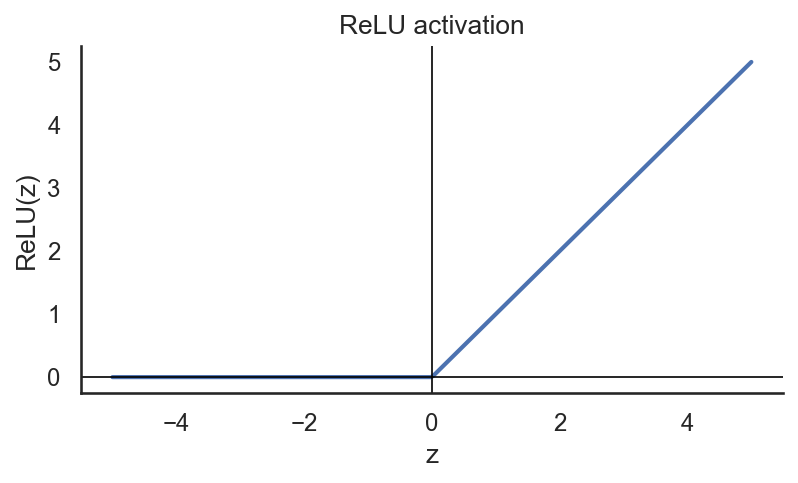

In [2]:
z = np.linspace(-5, 5, 300)
relu_values = np.maximum(0, z)

fig, ax = plt.subplots(figsize=(5.5, 3.4))
sns.lineplot(x=z, y=relu_values, linewidth=2, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("ReLU activation")
ax.set_xlabel("z")
ax.set_ylabel("ReLU(z)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 4. Sigmoid

Sigmoid 的定义是：

$$
\sigma(z) = \frac{1}{1 + \exp(-z)}
$$

它会把任意实数压缩到 0 到 1 之间。sigmoid 在二分类和概率建模中很重要，但在深层网络的隐藏层里，它可能出现梯度变小的问题。这里先把它作为一个重要概念认识清楚。

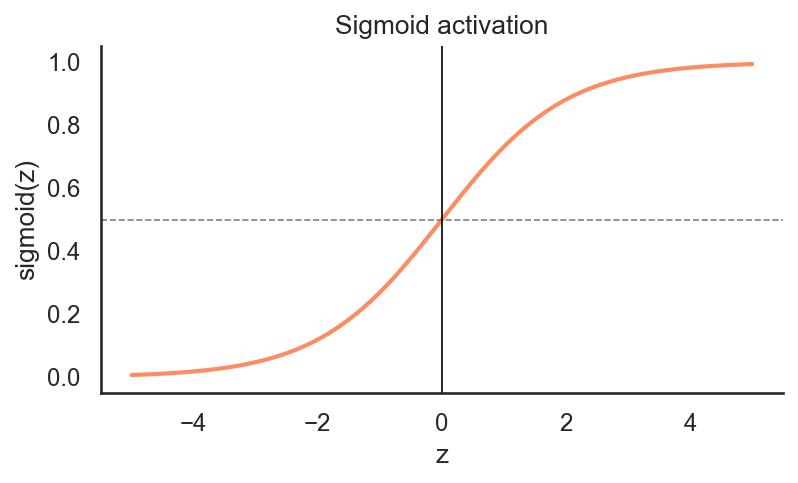

In [3]:
sigmoid_values = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(5.5, 3.4))
sns.lineplot(x=z, y=sigmoid_values, linewidth=2, color=sns.color_palette("Set2")[1], ax=ax)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Sigmoid activation")
ax.set_xlabel("z")
ax.set_ylabel("sigmoid(z)")
ax.set_ylim(-0.05, 1.05)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

下面把 ReLU 和 sigmoid 放在一起比较。ReLU 不会把正数压缩到 0 到 1；sigmoid 会饱和到接近 0 或接近 1。

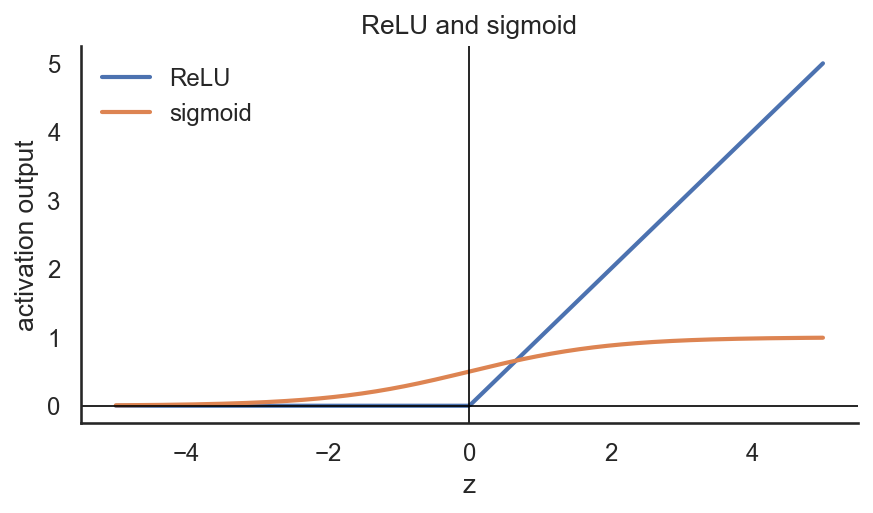

In [4]:
activation_df = pd.DataFrame(
    {
        "z": np.concatenate([z, z]),
        "activation value": np.concatenate([relu_values, sigmoid_values]),
        "activation": ["ReLU"] * len(z) + ["sigmoid"] * len(z),
    }
)

fig, ax = plt.subplots(figsize=(6, 3.6))
sns.lineplot(data=activation_df, x="z", y="activation value", hue="activation", linewidth=2, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("ReLU and sigmoid")
ax.set_xlabel("z")
ax.set_ylabel("activation output")
ax.legend(title=None, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 5. 什么是 MLP？

MLP 是 multilayer perceptron 的缩写，中文常叫多层感知机。最基本的 MLP 由这些部分组成：

- 输入层：例如 MNIST 图片 flatten 后的 784 个像素特征。
- 隐藏层：学习中间表示，例如 128 个 hidden units。
- 激活函数：例如 ReLU，给模型加入非线性。
- 输出层：输出 10 个 logits，对应数字 0 到 9。

本 notebook 使用的 MLP 是：

```text
784 input features -> Linear -> ReLU -> Linear -> 10 logits
```

它比 logistic regression 多了一个隐藏层，因此可以学习更复杂的非线性模式。

## 6. 准备 MNIST 数据

和前一个 notebook 一样，我们把每张 $28 \times 28$ 图片 flatten 成 784 维向量。

In [5]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

print(f"number of training images = {len(train_dataset)}")
print(f"number of test images = {len(test_dataset)}")

number of training images = 60000
number of test images = 10000


## 7. 超参数

除了 logistic regression 里的 `BATCH_SIZE`、`LEARNING_RATE`、`EPOCHS`，MLP 还多了一个重要超参数：

- `HIDDEN_SIZE`: 隐藏层有多少个 hidden units。

`HIDDEN_SIZE` 越大，模型容量通常越强，但训练也更慢，并且更容易过拟合。这里使用 128，足够演示概念。

In [6]:
BATCH_SIZE = 128
HIDDEN_SIZE = 128
LEARNING_RATE = 0.1
EPOCHS = 30

# Set this to True for a quick smoke test before class.
FAST_DEV_RUN = False

if FAST_DEV_RUN:
    train_dataset = Subset(train_dataset, range(2048))
    test_dataset = Subset(test_dataset, range(512))
    EPOCHS = 1

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"batch size = {BATCH_SIZE}")
print(f"hidden size = {HIDDEN_SIZE}")
print(f"learning rate = {LEARNING_RATE}")
print(f"epochs = {EPOCHS}")

batch size = 128
hidden size = 128
learning rate = 0.1
epochs = 30


## 8. 定义两层 MLP

`nn.Sequential` 会按顺序执行里面的模块。这里的模型只有三步：

1. `nn.Linear(784, HIDDEN_SIZE)`: 从 784 维像素向量得到隐藏层 pre-activation。
2. `nn.ReLU()`: 加入非线性。
3. `nn.Linear(HIDDEN_SIZE, 10)`: 输出 10 个 logits。

最后一层后面不加 softmax，因为 `nn.CrossEntropyLoss()` 需要 raw logits。

In [7]:
model = nn.Sequential(
    nn.Linear(28 * 28, HIDDEN_SIZE),
    nn.ReLU(),
    nn.Linear(HIDDEN_SIZE, 10),
).to(device)

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)


检查一个 mini-batch 经过 MLP 后的形状。

In [8]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

# Flatten images: (B, 1, 28, 28) -> (B, 784).
X = images.view(images.shape[0], -1)
logits = model(X)

print(f"X.shape = {tuple(X.shape)}")
print(f"logits.shape = {tuple(logits.shape)}")

X.shape = (128, 784)
logits.shape = (128, 10)


为了看清楚中间隐藏层，我们也可以把第一层和 ReLU 单独拿出来运行一次。

In [9]:
first_linear_layer = model[0]
relu_layer = model[1]

hidden_pre_activation = first_linear_layer(X)
hidden = relu_layer(hidden_pre_activation)

print(f"hidden_pre_activation.shape = {tuple(hidden_pre_activation.shape)}")
print(f"hidden.shape after ReLU = {tuple(hidden.shape)}")
print(f"fraction of hidden values equal to 0 = {(hidden == 0).float().mean().item():.3f}")

hidden_pre_activation.shape = (128, 128)
hidden.shape after ReLU = (128, 128)


fraction of hidden values equal to 0 = 0.452


## 9. Loss 和 optimizer

训练 MLP 的基本流程和 logistic regression 完全一样：

```python
optimizer.zero_grad()
logits = model(X)
loss = criterion(logits, labels)
loss.backward()
optimizer.step()
```

区别只在于 `model(X)` 里面多了一层隐藏层和 ReLU。

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

## 10. 训练循环

下面从头初始化模型并训练。每个 epoch 结束后记录平均 loss 和 training accuracy。

In [11]:
torch.manual_seed(SEED)
model = nn.Sequential(
    nn.Linear(28 * 28, HIDDEN_SIZE),
    nn.ReLU(),
    nn.Linear(HIDDEN_SIZE, 10),
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # The MLP still receives flattened image vectors.
        X = images.view(images.shape[0], -1)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += batch_size

    train_loss = total_loss / total
    train_accuracy = correct / total
    history.append({"epoch": epoch + 1, "train_loss": train_loss, "train_accuracy": train_accuracy})

    print(f"epoch {epoch + 1}: loss = {train_loss:.4f}, train accuracy = {train_accuracy:.4f}")

history_df = pd.DataFrame(history)
history_df

epoch 1: loss = 0.5707, train accuracy = 0.8548
epoch 2: loss = 0.2933, train accuracy = 0.9163
epoch 3: loss = 0.2404, train accuracy = 0.9323
epoch 4: loss = 0.2038, train accuracy = 0.9426
epoch 5: loss = 0.1776, train accuracy = 0.9494
epoch 6: loss = 0.1575, train accuracy = 0.9554
epoch 7: loss = 0.1408, train accuracy = 0.9603
epoch 8: loss = 0.1276, train accuracy = 0.9647
epoch 9: loss = 0.1162, train accuracy = 0.9677
epoch 10: loss = 0.1067, train accuracy = 0.9703
epoch 11: loss = 0.0985, train accuracy = 0.9728
epoch 12: loss = 0.0915, train accuracy = 0.9745
epoch 13: loss = 0.0852, train accuracy = 0.9765
epoch 14: loss = 0.0798, train accuracy = 0.9786
epoch 15: loss = 0.0751, train accuracy = 0.9792
epoch 16: loss = 0.0709, train accuracy = 0.9808
epoch 17: loss = 0.0667, train accuracy = 0.9817
epoch 18: loss = 0.0633, train accuracy = 0.9828
epoch 19: loss = 0.0600, train accuracy = 0.9836
epoch 20: loss = 0.0571, train accuracy = 0.9844
epoch 21: loss = 0.0543, trai

,epoch,train_loss,train_accuracy
0,1,0.570654,0.854817
1,2,0.293272,0.916317
2,3,0.240413,0.932267
3,4,0.203841,0.942617
4,5,0.177633,0.949433
5,6,0.157464,0.955400
6,7,0.140823,0.960317
7,8,0.127557,0.964733
8,9,0.116167,0.967733
9,10,0.106663,0.970283


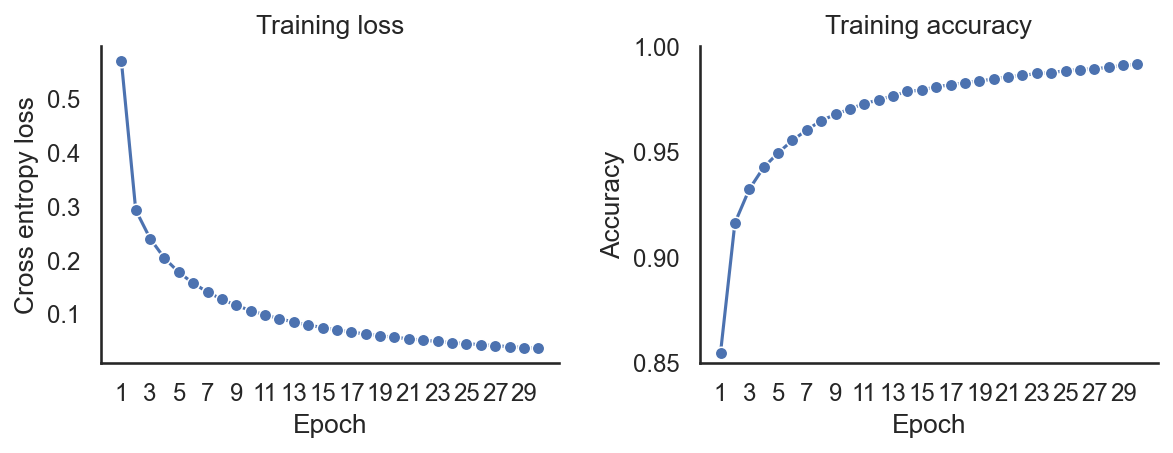

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

sns.lineplot(data=history_df, x="epoch", y="train_loss", marker="o", ax=axes[0])
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross entropy loss")
axes[0].set_xticks(history_df["epoch"])

sns.lineplot(data=history_df, x="epoch", y="train_accuracy", marker="o", ax=axes[1])
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.85, 1)
axes[1].set_xticks(history_df["epoch"])

xticks = history_df["epoch"][::2]

for axis in axes:
    axis.set_xticks(xticks)
    sns.despine(ax=axis)

plt.tight_layout()
plt.show()

## 11. 在 test set 上汇报 accuracy

和前一个 notebook 一样，测试时只做 forward pass，不计算梯度。

In [13]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        X = images.view(images.shape[0], -1)
        logits = model(X)
        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.shape[0]

test_accuracy = correct / total
print(f"test accuracy = {test_accuracy:.4f}")

test accuracy = 0.9770


## 12. 可以自己尝试的调参问题

保持任务相同，尝试改变这些设置：

- 把 `HIDDEN_SIZE` 改成 `32`、`128`、`256`，模型效果和训练速度有什么变化？
- 把 `LEARNING_RATE` 改成 `0.01`、`0.1`、`0.5`，loss 曲线有什么变化？
- 把 `nn.ReLU()` 换成 `nn.Sigmoid()`，accuracy 和训练速度有什么变化？
- 把 `EPOCHS` 改的更大，test accuracy 是否继续提高？

重点是观察：加入隐藏层和非线性后，模型是否比单层 logistic regression 更灵活。